# Import Libraries and Functions

In [1]:
import sys
import importlib
import joblib
import os
import math
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import time
from tqdm import tqdm
import gc

import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import MinMaxScaler

2026-09-09 13:29:12.523642: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-09 13:29:12.557051: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-09 13:29:12.557080: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-09 13:29:12.558160: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-09 13:29:12.564705: I tensorflow/core/platform/cpu_feature_guar

In [2]:
sys.path.append("../../analysis_tools")

In [3]:
# importlib.reload(data_extraction)
from data_extraction import DataExtraction2D
# import data_plot

# importlib.reload(data_plot)  
from data_plot import DataPlot
import data_calculation

# import modelData_processor
# importlib.reload(modelData_processor)
from modelData_processor import ModelDataProcessor

# import model_Analysis
# importlib.reload(model_Analysis)
from model_Analysis import ModelAnalysis
from sklearn.metrics import r2_score, mean_squared_error

# Data Preparation

In [4]:
data_extractor = DataExtraction2D()

In [5]:
df_output = data_extractor.GetScenariosToPD(filename = "../../Data/DUCK_SWAN_Data/swan_Log_DUCK.txt")

     Wind Value Wind Direction Wave Height Wave Direction  Iterations
0             1              0         1.6            -20          13
1             1              0         1.6              0          14
2             1              0         1.6             20          16
3             1              0         1.6             40          18
4             1              0         1.6             60          19
...         ...            ...         ...            ...         ...
3835          8            315         2.6             80          19
3836          8            315         2.6            100          18
3837          8            315         2.6            120          18
3838          8            315         2.6            140          15
3839          8            315         2.6            160          14

[3840 rows x 5 columns]


In [6]:
df_converged = df_output[df_output['Iterations'] != 50]
print(df_converged)

     Wind Value Wind Direction Wave Height Wave Direction  Iterations
0             1              0         1.6            -20          13
1             1              0         1.6              0          14
2             1              0         1.6             20          16
3             1              0         1.6             40          18
4             1              0         1.6             60          19
...         ...            ...         ...            ...         ...
3835          8            315         2.6             80          19
3836          8            315         2.6            100          18
3837          8            315         2.6            120          18
3838          8            315         2.6            140          15
3839          8            315         2.6            160          14

[3840 rows x 5 columns]


In [7]:
relevant_keys = set(
    zip(
        df_converged["Wind Value"].astype(int),
        df_converged["Wind Direction"].astype(int),
        df_converged["Wave Height"].astype(float),
        df_converged["Wave Direction"].astype(int),
    )
)

In [8]:
hsig_data = data_extractor.get_specific_data("../../Data/DUCK_SWAN_Data/DUCK_training_hsig.txt", 'hsig', relevant_keys)
forces_data = data_extractor.get_specific_data("../../Data/DUCK_SWAN_Data/DUCK_training_forces.txt", 'forces', relevant_keys)

In [9]:
df = data_extractor.DataConcat(relevant_keys, hsig_data, forces_data)

In [10]:
df_xp= pd.read_csv('../../Data/DUCK_SWAN_Data/2d_duck_xp.txt', sep='\t', header=None)
df_yp= pd.read_csv('../../Data/DUCK_SWAN_Data/2d_duck_yp.txt', sep='\t', header=None)
xp_vector = df_xp.values.flatten()
yp_vector = df_yp.values.flatten()

In [11]:
with open("../../Data/DUCK_SWAN_Data/DUCK_dataset.pkl", "rb") as f:
    loaded_data = pickle.load(f)

train_data = loaded_data["train"]
val_data = loaded_data["val"]
test_data = loaded_data["test"]

In [12]:
df["key"] = list(zip(df["Wind Value"], df["Wind Direction"], df["Wave Height"], df["Wave Direction"]))
test_df = df[df["key"].isin(test_data)]

# MLP prediction

In [13]:
def prepare_vectorized_mlp_inputs(df):
    speeds = df['Wind Value'].values.astype(np.float32)
    wind_dirs_rad = np.radians(df['Wind Direction'].values.astype(np.float32))

    wave_heights = df['Wave Height'].values.astype(np.float32)
    wave_dirs_rad = np.radians(df['Wave Direction'].values.astype(np.float32)

)

    x_wind = speeds * np.cos(wind_dirs_rad)
    y_wind = speeds * np.sin(wind_dirs_rad)

    cos_wave_dir = np.cos(wave_dirs_rad)
    sin_wave_dir = np.sin(wave_dirs_rad)

    return np.column_stack(
        (x_wind, y_wind, wave_heights, cos_wave_dir, sin_wave_dir)
    )

In [14]:
def extract_truth(row, component, water_mask):
    
    if component == "hsig":
        full = np.array(row["Hsig Data"], dtype=np.float32)
        return full[water_mask]

    elif component == "xforces":
        forces = np.array(row["Forces Data"], dtype=np.float32)
        return forces[:, 0][water_mask]

    elif component == "yforces":
        forces = np.array(row["Forces Data"], dtype=np.float32)
        return forces[:, 1][water_mask]

    else:
        raise ValueError(f"Unknown component: {component}")

In [15]:
def evaluate_model(
    test_df,
    model_path,
    metadata_path,
    component,
    scenario_key_column="Scenario Key"
):
    
    with open(metadata_path, "rb") as f:
        meta = pickle.load(f)

    X_raw = prepare_vectorized_mlp_inputs(test_df)

    X_norm = meta["input_scaler"].transform(X_raw)

    model = models.load_model(model_path)

    pred_norm = model.predict(X_norm, verbose=0)

    pred = (
        pred_norm
        * (meta[f"max_{component}"] - meta[f"min_{component}"])
        + meta[f"min_{component}"]
    )

    scenario_hsig = np.array(
        test_df.iloc[0]["Hsig Data"],
        dtype=np.float32
    )

    water_mask = scenario_hsig != -9.0

    num_water_points = np.sum(water_mask)
    num_samples = len(test_df)

    Y_true = np.zeros(
        (num_samples, num_water_points),
        dtype=np.float32
    )

    for i, (_, row) in enumerate(test_df.iterrows()):
        Y_true[i] = extract_truth(
            row,
            component,
            water_mask
        )
    
    diff_vec = Y_true - pred
    error_norm = np.linalg.norm(diff_vec, ord=2, axis=1)
    true_norm = np.linalg.norm(Y_true , ord=2, axis=1)

    relative_l2 = error_norm / (true_norm + 1e-8)

    scenario_results = {}

    for idx, (_, row) in enumerate(test_df.iterrows()):

        scenario_key = row[scenario_key_column]

        scenario_results[scenario_key] = {
            "relative_l2": float(relative_l2[idx]),
            "prediction": pred[idx],
            "truth": Y_true[idx]
        }

    summary = {
        "min": float(relative_l2.min()),
        "max": float(relative_l2.max()),
        "median": float(np.median(relative_l2)),
        "mean": float(relative_l2.mean())
    }

    return {
        "component": component,
        "relative_l2": relative_l2,
        "summary": summary,
        "scenario_results": scenario_results
    }

In [16]:
MODEL_CONFIG = {

    "hsig": {
        "model_path":
            "../../Models/mlp/mlp_2L/740164/mlp_duck_hsig/wave_mlp_duck_model_hsig.keras",

        "metadata_path":
            "../../Models/mlp/mlp_2L/740164/mlp_duck_hsig/model_normalization_metadata_hsig.pkl"
    },

    "xforces": {
        "model_path":
            "../../Models/mlp/mlp_2L/740165/mlp_duck_xforces/wave_mlp_duck_model_xforces.keras",

        "metadata_path":
            "../../Models/mlp/mlp_2L/740165/mlp_duck_xforces/model_normalization_metadata_xforces.pkl"
    },

    "yforces": {
        "model_path":
            "../../Models/mlp/mlp_2L/740166/mlp_duck_yforces/wave_mlp_duck_model_yforces.keras",

        "metadata_path":
            "../../Models/mlp/mlp_2L/740166/mlp_duck_yforces/model_normalization_metadata_yforces.pkl"
    }
}

In [17]:
all_results = {}

for component, cfg in MODEL_CONFIG.items():

    all_results[component] = evaluate_model(
        test_df=test_df,
        component=component,
        model_path=cfg["model_path"],
        metadata_path=cfg["metadata_path"],
        scenario_key_column="key"
    )

    print(component)
    print(all_results[component]["summary"])

/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
2026-09-09 13:30:18.702821: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 43502 MB memory:  -> device: 0, name: NVIDIA L40S, pci bus id: 0000:be:00.0, compute capability: 8.9
2026-09-09 13:30:19.397533: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


hsig
{'min': 0.0039191232062876225, 'max': 0.042735639959573746, 'median': 0.010307559743523598, 'mean': 0.011669393628835678}


/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


xforces
{'min': 0.03729920834302902, 'max': 0.31416305899620056, 'median': 0.09709284454584122, 'mean': 0.10181979089975357}


/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


yforces
{'min': 0.03208751231431961, 'max': 0.15402856469154358, 'median': 0.062414683401584625, 'mean': 0.06623324751853943}


In [18]:
MODEL_CONFIG_LARGE = {

    "hsig": {
        "model_path":
            "../../Models/mlp/mlp_3L/743359/mlp_duck_hsig/wave_mlp_duck_model_hsig.keras",

        "metadata_path":
            "../../Models/mlp/mlp_3L/743359/mlp_duck_hsig/model_normalization_metadata_hsig.pkl"
    },

    "xforces": {
        "model_path":
            "../../Models/mlp/mlp_3L/743360/mlp_duck_xforces/wave_mlp_duck_model_xforces.keras",

        "metadata_path":
            "../../Models/mlp/mlp_3L/743360/mlp_duck_xforces/model_normalization_metadata_xforces.pkl"
    },

    "yforces": {
        "model_path":
            "../../Models/mlp/mlp_3L/743361/mlp_duck_yforces/wave_mlp_duck_model_yforces.keras",

        "metadata_path":
            "../../Models/mlp/mlp_3L/743361/mlp_duck_yforces/model_normalization_metadata_yforces.pkl"
    }
}

In [19]:
all_results_large = {}

for component, cfg in MODEL_CONFIG_LARGE.items():

    all_results_large[component] = evaluate_model(
        test_df=test_df,
        component=component,
        model_path=cfg["model_path"],
        metadata_path=cfg["metadata_path"],
        scenario_key_column="key"
    )

/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator 

In [20]:
print(all_results_large['hsig']["summary"])
print(all_results_large['xforces']["summary"])
print(all_results_large['yforces']["summary"])

{'min': 0.00041564274579286575, 'max': 0.013052578084170818, 'median': 0.0009940504096448421, 'mean': 0.001963521121069789}
{'min': 0.0027801271062344313, 'max': 0.05128506198525429, 'median': 0.008172067813575268, 'mean': 0.009774175472557545}
{'min': 0.002699438016861677, 'max': 0.042573437094688416, 'median': 0.006853280123323202, 'mean': 0.008467957377433777}


In [21]:

results_y = ModelAnalysis.compute_metrics_comprehensive(     
    test_df=test_df,
    xp_vector=xp_vector,
    yp_vector=yp_vector,
    model_dir="../../Models/model_DUCK_yforces",
    component="y")

results_x = ModelAnalysis.compute_metrics_comprehensive(     
    test_df=test_df,
    xp_vector=xp_vector,
    yp_vector=yp_vector,
    model_dir="../../Models/model_DUCK_xforces",
    component="x",)

results_h = ModelAnalysis.compute_metrics_comprehensive(     
    test_df=test_df,
    xp_vector=xp_vector,
    yp_vector=yp_vector,
   model_dir="../../Models/model_DUCK_Hsig",
    component="hsig",
    )


/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.3.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.3.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinM

In [22]:
print("DeepONet Hsig")

print("Mean   :", results_h["mean_rel_l2"])
print("Median :", results_h["median_rel_l2"])
print("Max    :", np.max(results_h["rel_l2_per_case"]))
print("Min    :", np.min(results_h["rel_l2_per_case"]))

DeepONet Hsig
Mean   : 0.005563691328198028
Median : 0.005122517440507493
Max    : 0.01909273805918982
Min    : 0.002893583039697455


In [23]:
print("DeepONet XForces")

print("Mean   :", results_x["mean_rel_l2"])
print("Median :", results_x["median_rel_l2"])
print("Max    :", np.max(results_x["rel_l2_per_case"]))
print("Min    :", np.min(results_x["rel_l2_per_case"]))

DeepONet XForces
Mean   : 0.034621875054833974
Median : 0.03269547961321886
Max    : 0.10377029730759445
Min    : 0.023894149882888505


In [24]:
print("DeepONet YForces")

print("Mean   :", results_y["mean_rel_l2"])
print("Median :", results_y["median_rel_l2"])
print("Max    :", np.max(results_y["rel_l2_per_case"]))
print("Min    :", np.min(results_y["rel_l2_per_case"]))

DeepONet YForces
Mean   : 0.02674218495485487
Median : 0.025552766920596333
Max    : 0.0688370320562402
Min    : 0.017758957624602598


In [25]:
deepo_hsig = {
    key: l2
    for key, l2 in zip(
        results_h["scenario_keys"],
        results_h["rel_l2_per_case"]
    )
}


In [26]:
deepo_xforces = {
    key: l2
    for key, l2 in zip(
        results_x["scenario_keys"],
        results_x["rel_l2_per_case"]
    )
}

deepo_yforces = {
    key: l2
    for key, l2 in zip(
        results_y["scenario_keys"],
        results_y["rel_l2_per_case"]
    )
}

In [27]:

plot_rows = []

# Hsig
for key in all_results["hsig"]["scenario_results"]:

    plot_rows.append({
        "Variable": "Hsig",
        "Model": "MLP-2L",
        "L2": all_results["hsig"]["scenario_results"][key]["relative_l2"]
    })

    plot_rows.append({
        "Variable": "Hsig",
        "Model": "MLP-3L",
        "L2": all_results_large["hsig"]["scenario_results"][key]["relative_l2"]
    })

    plot_rows.append({
        "Variable": "Hsig",
        "Model": "DeepONet",
        "L2": deepo_hsig[key]
    })


# X Forces
for key in all_results["xforces"]["scenario_results"]:

    plot_rows.append({
        "Variable": "XForce",
        "Model": "MLP-2L",
        "L2": all_results["xforces"]["scenario_results"][key]["relative_l2"]
    })

    plot_rows.append({
        "Variable": "XForce",
        "Model": "MLP-3L",
        "L2": all_results_large["xforces"]["scenario_results"][key]["relative_l2"]
    })

    plot_rows.append({
        "Variable": "XForce",
        "Model": "DeepONet",
        "L2": deepo_xforces[key]
    })


# Y Forces
for key in all_results["yforces"]["scenario_results"]:

    plot_rows.append({
        "Variable": "YForce",
        "Model": "MLP-2L",
        "L2": all_results["yforces"]["scenario_results"][key]["relative_l2"]
    })

    plot_rows.append({
        "Variable": "YForce",
        "Model": "MLP-3L",
        "L2": all_results_large["yforces"]["scenario_results"][key]["relative_l2"]
    })

    plot_rows.append({
        "Variable": "YForce",
        "Model": "DeepONet",
        "L2": deepo_yforces[key]
    })

df_violin = pd.DataFrame(plot_rows)

print(df_violin.head())


  Variable     Model        L2
0     Hsig    MLP-2L  0.010072
1     Hsig    MLP-3L  0.001071
2     Hsig  DeepONet  0.002926
3     Hsig    MLP-2L  0.009386
4     Hsig    MLP-3L  0.000641


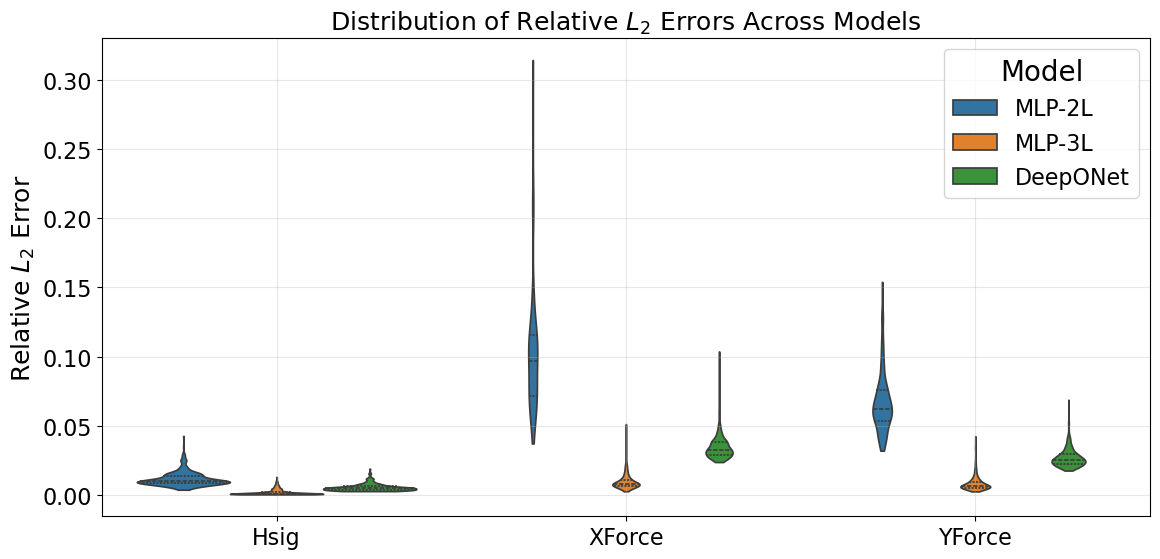

In [28]:
import seaborn as sns

plt.figure(figsize=(12,6))

sns.violinplot(
    data=df_violin,
    x="Variable",
    y="L2",
    hue="Model",
    cut=0,
    inner="quartile"
)

plt.ylabel("Relative $L_2$ Error")
plt.xlabel("")
plt.title("Distribution of Relative $L_2$ Errors Across Models")

plt.grid(alpha=0.3)
plt.tight_layout()

# plt.savefig(
#     "ViolinPlot_9Models.pdf",
#     bbox_inches="tight"
# )

plt.show()